In [1]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [4]:
X

array([[-4.6899551 ,  2.92448482],
       [ 9.5652714 ,  0.33635903],
       [-6.64504276,  1.31457118],
       ...,
       [ 9.56126845,  0.61340864],
       [-5.34600058,  1.81382489],
       [-8.38803596,  1.51232443]])

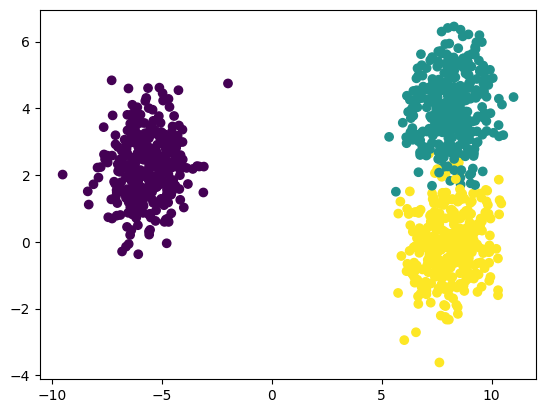

In [7]:
plt.scatter(X[:,0],X[:,1],c = y)

In [8]:
## standardization --feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state=42)

In [12]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.cluster import KMeans

In [ ]:
## Elbow method to select k value
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [23]:
wcss

[1339.9999999999995,
 683.3247157781228,
 176.88618099355037,
 131.46662593820844,
 97.00666870734887,
 70.76887270466088,
 60.40166655924497,
 50.58240777803897,
 43.47649297851689,
 38.56781183551991]

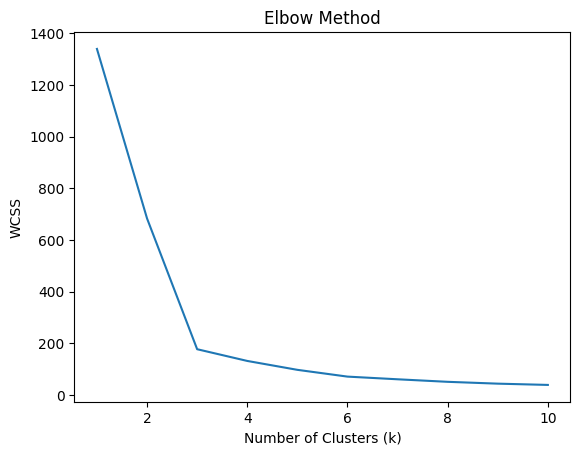

In [26]:
# Plotting the elbow graph
plt.figure()
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

In [27]:
kmeans = KMeans(n_clusters=3 , init="k-means++")

In [ ]:
kmeans.fit_predict(X_train_scaled)

In [30]:
y_pred = kmeans.predict(X_test_scaled)

In [ ]:
y_pred

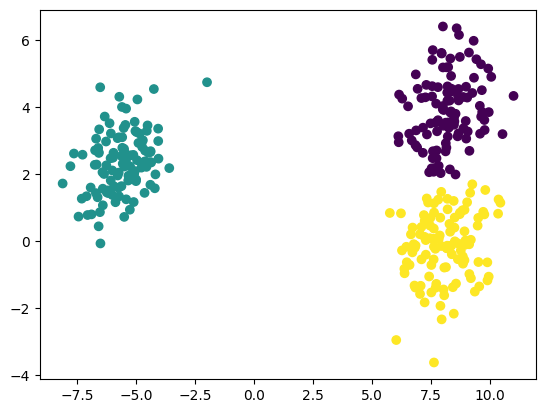

In [33]:
plt.scatter(X_test[:,0],X_test[:,1],c = y_pred)

In [34]:
## Validating the k value
##Kneelocator
##Silhoutee scoring

In [ ]:
##kneelocator
!pip install kneed

In [38]:
from kneed import KneeLocator

In [40]:
kl = KneeLocator(range(1,11),wcss,curve = "convex",direction="decreasing")

In [41]:
kl.elbow

3

In [42]:
##silhoutte score
from sklearn.metrics import silhouette_score

In [ ]:
silhoutee_cofficients = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)

    silhoutee_cofficients.append(score)

In [44]:
silhoutee_cofficients

[0.5407585765613064,
 0.699493686606053,
 0.6113414790049078,
 0.5361312172415376,
 0.4858500198088556,
 0.4592820937925706,
 0.4390762416426189,
 0.41027779831463235,
 0.4139252250450047]

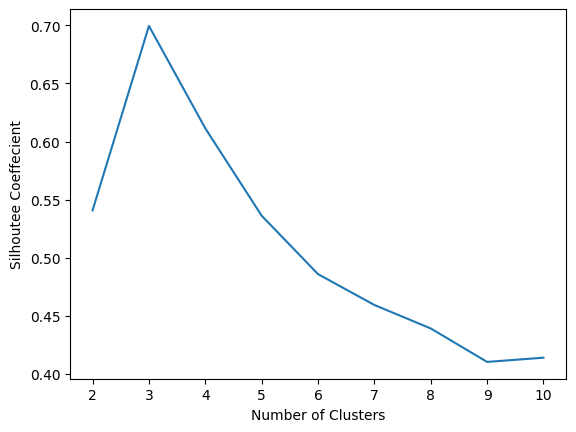

In [47]:
# Plotting the silhoutee score
plt.figure()
plt.plot(range(2, 11), silhoutee_cofficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhoutee Coeffecient")
plt.show()